In [ ]:
import pm4py
#from synthetical_log_generation.log_generator import create_translucent_event_log
from pm4py.objects.conversion.log import converter as log_converter
import pickle
import os
import pandas as pd
import numpy as np
import Soccer_OCEL.isolation_forest as isolation_forest
import Soccer_OCEL.utils as utils

#from translucent_discovery.translucent_inductive_miner.translucent_base import discover_petri_net
#from translucent_precision.main import translucent_precision_score

from pm4py.algo.evaluation import algorithm as general_evaluation
from pm4py.algo.transformation.log_to_features.variants import trace_based
import pandas as pd
from sklearn.ensemble import IsolationForest
from pm4py.algo.label_splitting import algorithm as label_splitter

In [ ]:
path='data/28196177'
#games=get_games(path)#load all 7 games
games=['J03WQQ', 'J03WR9', 'J03WPY', 'J03WOH', 'J03WOY'] #Fortuna Düsseldorf games
#games=['J03WQQ', 'J03WOH', 'J03WOY'] #Fortuna Düsseldorf, won game
#games=['J03WR9', 'J03WPY'] #Fortuna Düsseldorf lost game
all_games=[]
for Game in games:
    with open(os.path.join('/Users/vitochan/Documents/phd/Projects/Soccer/IDSSE_notebooks/output'
                           ,'output_pkl',f"GameData_{Game}_noposition.pkl"), "rb") as f:
        GD_loaded = pickle.load(f)
        GD_loaded = utils.formatting(GD_loaded)
        all_games.append(GD_loaded)
logs=[game.events for game in all_games]
log_df=pd.concat(logs).sort_values('time:timestamp').reset_index(drop=True)
# log = pm4py.convert_to_event_log(log_df)

In [14]:
log_df

,level_0,concept:name,attribute:gameclock,tID,Player,attribute:outcome,time:timestamp,minute,second,attribute:qualifier,...,PenaltyExecution,PenaltyDirection,AssistFouledPlayer,TypeOfPossessionLoss,PossessionLossOrigin,ChangeOfCaptain,ChangeContingentExhausted,PlayerBecomesGoalkeeper,Error,@@index
0,0.0,KickOff_Play_Pass,0.000,DFL-CLU-000011,DFL-OBJ-002GAB,1.0,2022-08-26 16:32:08.110000+00:00,0.0,0.0,"{'GameSection': 'firstHalf', 'TeamRight': 'DFL...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,1.0,Play_Pass_0,5.702,DFL-CLU-000011,DFL-OBJ-00268T,1.0,2022-08-26 16:32:13.812000+00:00,0.0,5.0,"{'Recipient': 'DFL-OBJ-002G2Y', 'Height': 'hig...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,2.0,TacklingGame,6.719,DFL-CLU-000011,DFL-OBJ-002G2Y,0.0,2022-08-26 16:32:14.829000+00:00,0.0,6.0,"{'PossessionChange': 'false', 'WinnerTeam': 'D...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
3,3.0,Play_Pass_0,9.430,DFL-CLU-000011,DFL-OBJ-002G2Y,1.0,2022-08-26 16:32:17.540000+00:00,0.0,9.0,"{'Recipient': 'DFL-OBJ-0027XP', 'Height': 'hig...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
4,4.0,OtherBallAction,10.182,DFL-CLU-000011,DFL-OBJ-0027XP,NaN,2022-08-26 16:32:18.292000+00:00,0.0,10.0,"{'Player': 'DFL-OBJ-0027XP', 'BallPossessionPh...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10130,1371.0,Play_Pass_Received_0,2975.380,DFL-CLU-00000I,DFL-OBJ-0000F9,NaN,2022-11-11 19:22:58.400000+00:00,49.0,2.0,"{'Player': 'DFL-OBJ-002GPN', 'Distance': 'shor...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10130
10131,1372.0,Pass_Intercepted,2976.007,DFL-CLU-00000P,DFL-OBJ-J01KJ5,NaN,2022-11-11 19:22:59.027000+00:00,49.0,3.0,"{'Player': 'DFL-OBJ-0000F9', 'Distance': 'medi...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10131
10132,1374.0,Play_Pass_Received_0,2979.967,DFL-CLU-00000P,DFL-OBJ-002G5J,NaN,2022-11-11 19:23:02.987000+00:00,49.0,7.0,"{'Player': 'DFL-OBJ-J01KJ5', 'Distance': 'shor...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10132
10133,1375.0,Pass_Intercepted,2981.679,DFL-CLU-00000I,DFL-OBJ-002G0F,NaN,2022-11-11 19:23:04.699000+00:00,49.0,9.0,"{'Player': 'DFL-OBJ-002G5J', 'Distance': 'medi...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10133


Dropped dict columns: ['attribute:qualifier']


/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/isolation_tree.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[f"{col}_0", f"{col}_1"]] = col_series.apply(
/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/isolation_tree.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[f"{col}_0", f"{col}_1"]] = col_series.apply(


{'avg': np.float64(0.13113054158944826), 'anonmaly_relative_frequency': np.float64(0.0006238303181534623)}
                            ano_traces_with_event  event_count_in_ano_log  \
SavedShot                                       1                       1   
ShotAtGoal                                      1                       1   
ThrowIn_Play_Pass_Received                      1                       1   
ThrowIn_Play_Pass                               1                       1   
OtherBallAction                                 1                       3   
TacklingGame                                    1                       2   
Play_Pass_Received_0                            1                       6   
Play_Pass_0                                     1                      10   

                            event_count_in_log  trace_fraction_in_anomalies  
SavedShot                                   34                     0.029412  
ShotAtGoal                                 

/Users/vitochan/Documents/phd/Projects/Soccer/.venv/lib/python3.11/site-packages/pm4py/algo/discovery/dfg/adapters/pandas/df_statistics.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[start_timestamp_key] = df[timestamp_key]


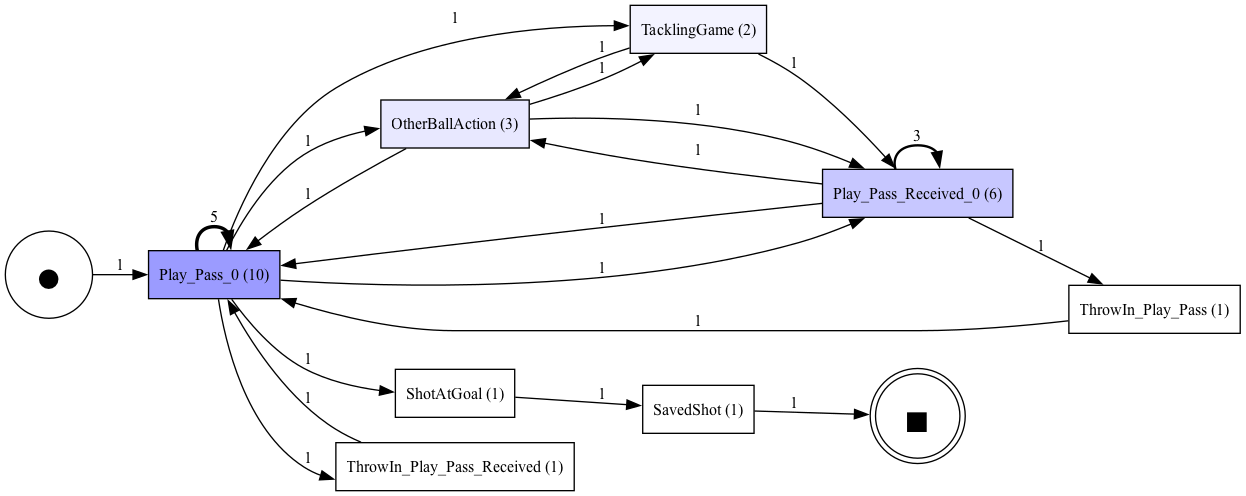

{'avg': np.float64(0.12955648286200105), 'anonmaly_relative_frequency': np.float64(0.0012476606363069245)}
                             ano_traces_with_event  event_count_in_ano_log  \
ThrowIn_Play_Cross_Received                      1                       1   
ThrowIn_Play_Cross                               1                       1   
SavedShot                                        1                       1   
ShotWide                                         1                       1   
ShotAtGoal                                       2                       2   
ThrowIn_Play_Pass_Received                       1                       1   
ThrowIn_Play_Pass                                1                       1   
OtherBallAction                                  2                       5   
TacklingGame                                     2                       4   
Play_Pass_Received_0                             2                      14   
Play_Pass_0                        

/Users/vitochan/Documents/phd/Projects/Soccer/.venv/lib/python3.11/site-packages/pm4py/algo/discovery/dfg/adapters/pandas/df_statistics.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[start_timestamp_key] = df[timestamp_key]


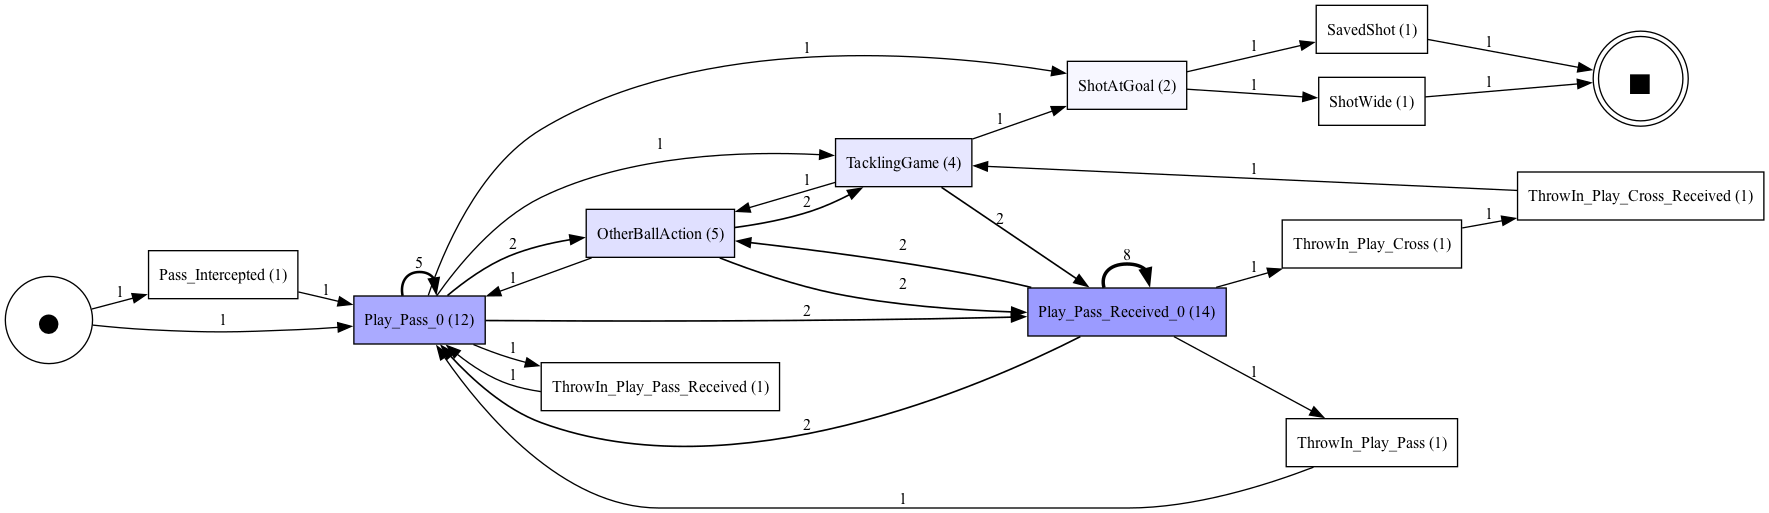

In [ ]:

#rlog = label_splitter.apply(initial_log, variant=label_splitter.Variants.CONTEXTUAL)

# relabeling with a single activity allowed in the prefix and suffix,
# plus the relabeling only applies to a given activity
log_df = label_splitter.apply(log_df, variant=label_splitter.Variants.CONTEXTUAL,
                                 parameters={#"prefix_length": 1, "suffix_length": 1,
                                             "target_activities": ["Play_Pass","Play_Cross",
                                                                   "Play_Pass_Intercepted", "Play_Pass_Received",
                                                                   "Play_Cross_Received", "Play_Cross_Intercepted"]})
log_df_encode, encoders=isolation_forest.encode_non_numeric(log_df)

##event based
anomalies, log_features_df, case_idlist, case_count_ano=isolation_forest.find_anom(log_df_encode)
dfg, start_activities, end_activities = pm4py.discover_dfg(anomalies)
pm4py.view_dfg(dfg, start_activities, end_activities)

##trace based
anomalies, log_features_df, case_idlist, case_count_ano=isolation_forest.find_anom(log_df_encode, variant='trace')
dfg, start_activities, end_activities = pm4py.discover_dfg(anomalies)
pm4py.view_dfg(dfg, start_activities, end_activities)

Dropped dict columns: ['attribute:qualifier']


/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/isolation_tree.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[f"{col}_0", f"{col}_1"]] = col_series.apply(
/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/isolation_tree.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[f"{col}_0", f"{col}_1"]] = col_series.apply(


{'avg': np.float64(0.12919080303733418), 'anonmaly_relative_frequency': np.float64(0.0025)}
                             ano_traces_with_event  event_count_in_ano_log  \
PossessionLossBeforeGoal                         1                       1   
ThrowIn_Play_Cross_Received                      1                       1   
Scored                                           1                       1   
ThrowIn_Play_Cross                               1                       1   
Nutmeg                                           1                       1   
ShotWide                                         1                       1   
ShotAtGoal                                       2                       2   
GoalKick_Play_Pass                               1                       1   
ThrowIn_Play_Pass                                1                       1   
TacklingGame                                     2                       3   
Pass_Intercepted                                 2

/Users/vitochan/Documents/phd/Projects/Soccer/.venv/lib/python3.11/site-packages/pm4py/algo/discovery/dfg/adapters/pandas/df_statistics.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[start_timestamp_key] = df[timestamp_key]


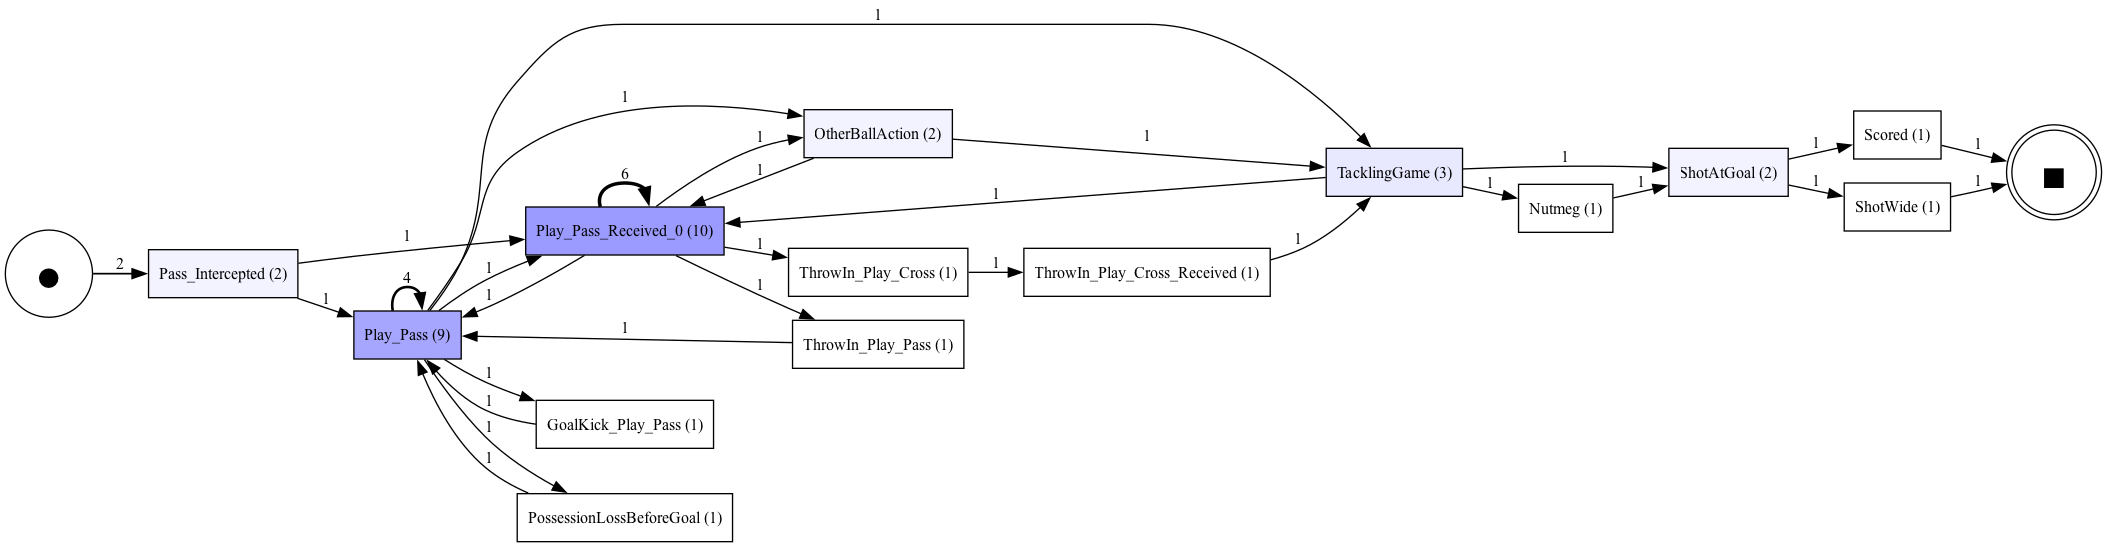

{'avg': np.float64(0.13413168896863292), 'anonmaly_relative_frequency': np.float64(0.00125)}
                             ano_traces_with_event  event_count_in_ano_log  \
ThrowIn_Play_Cross_Received                      1                       1   
ThrowIn_Play_Cross                               1                       1   
ShotWide                                         1                       1   
ShotAtGoal                                       1                       1   
OtherBallAction                                  1                       2   
TacklingGame                                     1                       2   
Pass_Intercepted                                 1                       1   
Play_Pass_Received_0                             1                       8   
Play_Pass                                        1                       2   

                             event_count_in_log  trace_fraction_in_anomalies  
ThrowIn_Play_Cross_Received                   2

/Users/vitochan/Documents/phd/Projects/Soccer/.venv/lib/python3.11/site-packages/pm4py/algo/discovery/dfg/adapters/pandas/df_statistics.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[start_timestamp_key] = df[timestamp_key]


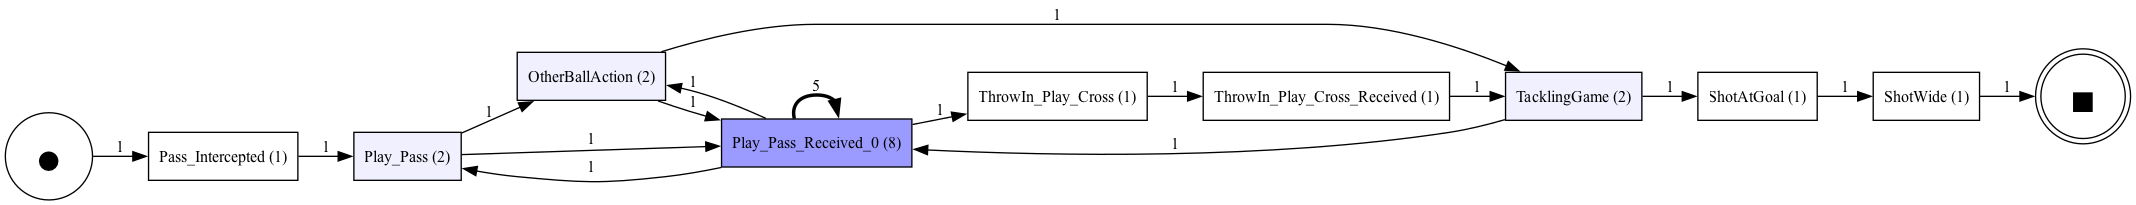

In [ ]:
##home
log_df=pd.concat(logs).sort_values('time:timestamp').reset_index(drop=True)
Home_df = log_df[log_df['case:concept:name'].str.contains('Home')]
log_df = label_splitter.apply(Home_df, variant=label_splitter.Variants.CONTEXTUAL,
                                 parameters={#"prefix_length": 1, "suffix_length": 1,
                                             "target_activities": ["Play_Pass","Play_Cross",
                                                                   "Play_Pass_Intercepted", "Play_Pass_Received",
                                                                   "Play_Cross_Received", "Play_Cross_Intercepted"]})
log_df_encode, encoders=isolation_forest.encode_non_numeric(log_df)
##event based
anomalies, log_features_df, case_idlist, case_count_ano=isolation_forest.find_anom(log_df_encode)
dfg, start_activities, end_activities = pm4py.discover_dfg(anomalies)
pm4py.view_dfg(dfg, start_activities, end_activities)

##trace based
anomalies, log_features_df, case_idlis, case_count_anot=isolation_forest.find_anom(log_df_encode, variant='trace')
dfg, start_activities, end_activities = pm4py.discover_dfg(anomalies)
pm4py.view_dfg(dfg, start_activities, end_activities)

Dropped dict columns: ['attribute:qualifier']


/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/isolation_tree.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[f"{col}_0", f"{col}_1"]] = col_series.apply(
/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/isolation_tree.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[f"{col}_0", f"{col}_1"]] = col_series.apply(


{'avg': np.float64(0.10773357589059904), 'anonmaly_relative_frequency': np.float64(0.007692307692307693)}
                    ano_traces_with_event  event_count_in_ano_log  \
BallDeflection                          1                       1   
ShotWoodWork                            1                       1   
Pass_Intercepted                        1                       1   
OtherBallAction                         1                       2   
Play_Pass_Received                      1                       2   
Play_Pass                               1                       2   
ShotAtGoal                              1                       1   

                    event_count_in_log  trace_fraction_in_anomalies  
BallDeflection                       1                     1.000000  
ShotWoodWork                         1                     1.000000  
Pass_Intercepted                    56                     0.017857  
OtherBallAction                    104                     0.

/Users/vitochan/Documents/phd/Projects/Soccer/.venv/lib/python3.11/site-packages/pm4py/algo/discovery/dfg/adapters/pandas/df_statistics.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[start_timestamp_key] = df[timestamp_key]


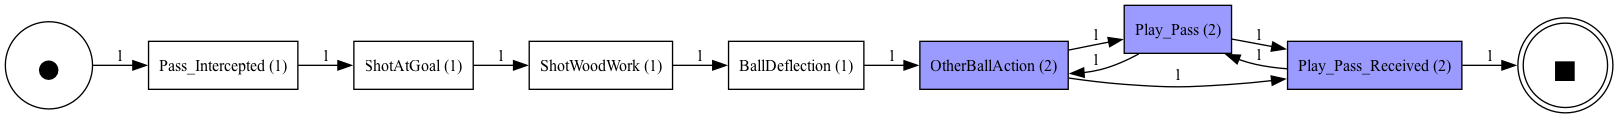

{'avg': np.float64(0.10827557573185609), 'anonmaly_relative_frequency': np.float64(0.007692307692307693)}
                    ano_traces_with_event  event_count_in_ano_log  \
BallDeflection                          1                       1   
ShotWoodWork                            1                       1   
Pass_Intercepted                        1                       1   
OtherBallAction                         1                       2   
Play_Pass_Received                      1                       2   
Play_Pass                               1                       2   
ShotAtGoal                              1                       1   

                    event_count_in_log  trace_fraction_in_anomalies  
BallDeflection                       1                     1.000000  
ShotWoodWork                         1                     1.000000  
Pass_Intercepted                    56                     0.017857  
OtherBallAction                    104                     0.

/Users/vitochan/Documents/phd/Projects/Soccer/.venv/lib/python3.11/site-packages/pm4py/algo/discovery/dfg/adapters/pandas/df_statistics.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[start_timestamp_key] = df[timestamp_key]


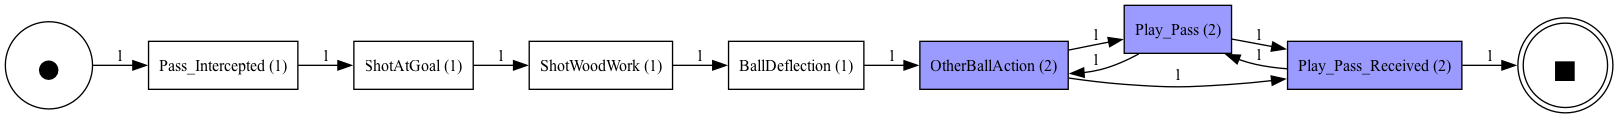

In [ ]:
##shots
log_df=pd.concat(logs).sort_values('time:timestamp').reset_index(drop=True)
shot_events=log_df[(log_df['concept:name'].str.contains('ShotAt'))]
shot_df = log_df[log_df['case:concept:name'].isin(shot_events['case:concept:name'])]
log_df = label_splitter.apply(shot_df, variant=label_splitter.Variants.CONTEXTUAL,
                                 parameters={#"prefix_length": 1, "suffix_length": 1,
                                             "target_activities": ["Play_Pass","Play_Cross",
                                                                   "Play_Pass_Intercepted", "Play_Pass_Received",
                                                                   "Play_Cross_Received", "Play_Cross_Intercepted"]})
log_df_encode, encoders=isolation_forest.encode_non_numeric(log_df)
##event based
anomalies, log_features_df, case_idlist, case_count_ano=isolation_forest.find_anom(log_df_encode)
dfg, start_activities, end_activities = pm4py.discover_dfg(anomalies)
pm4py.view_dfg(dfg, start_activities, end_activities)

##trace based
anomalies, log_features_df, case_idlis, case_count_anot=isolation_forest.find_anom(log_df_encode, variant='trace')
dfg, start_activities, end_activities = pm4py.discover_dfg(anomalies)
pm4py.view_dfg(dfg, start_activities, end_activities)

In [ ]:
##non shots
log_df=pd.concat(logs).sort_values('time:timestamp').reset_index(drop=True)
shot_events=log_df[(log_df['concept:name'].str.contains('Shot'))]
no_shot_df = log_df[~log_df['case:concept:name'].isin(shot_events['case:concept:name'])]
log_df = label_splitter.apply(no_shot_df, variant=label_splitter.Variants.CONTEXTUAL,
                                 parameters={#"prefix_length": 1, "suffix_length": 1,
                                             "target_activities": ["Play_Pass","Play_Cross",
                                                                   "Play_Pass_Intercepted", "Play_Pass_Received",
                                                                   "Play_Cross_Received", "Play_Cross_Intercepted"]})
log_df_encode, encoders=isolation_forest.encode_non_numeric(log_df)
##event based
anomalies, log_features_df, case_idlist, case_count_ano=isolation_forest.find_anom(log_df_encode)
dfg, start_activities, end_activities = pm4py.discover_dfg(anomalies)
pm4py.view_dfg(dfg, start_activities, end_activities)

##trace based
anomalies, log_features_df, case_idlis, case_count_anot=isolation_forest.find_anom(log_df_encode, variant='trace')
dfg, start_activities, end_activities = pm4py.discover_dfg(anomalies)
pm4py.view_dfg(dfg, start_activities, end_activities)

Dropped dict columns: ['attribute:qualifier']


/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/isolation_tree.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[f"{col}_0", f"{col}_1"]] = col_series.apply(
/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/isolation_tree.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[f"{col}_0", f"{col}_1"]] = col_series.apply(


{'avg': np.float64(0.1249697189299198), 'anonmaly_relative_frequency': np.float64(0.0)}
                                ano_traces_with_event  event_count_in_ano_log  \
concept:name                                                                    
Play_Pass_0                                         0                     0.0   
Nutmeg                                              0                     0.0   
Offside                                             0                     0.0   
RefereeBall                                         0                     0.0   
CornerKick_Play_Cross_Received                      0                     0.0   
SpectacularPlay                                     0                     0.0   
Play_Pass_Received_1                                0                     0.0   
FreeKick_Play_Cross                                 0                     0.0   
PenaltyNotAwarded                                   0                     0.0   
VideoAssistantAction 

/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/isolation_tree.py:123: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  case_count_ano_df = case_count_ano_df.fillna(0)


ValueError: min() arg is an empty sequence